In [2]:
# Install the World Bank API package (the '!' is required in Colab to run shell commands)
!pip install wbgapi

import wbgapi as wb
import pandas as pd
import sqlite3

# 1. Define the Population Dynamics indicators
# SP.DYN.LE00.IN: Life expectancy at birth, total (years) [cite: 35]
# SH.DYN.MORT: Mortality rate, under-5 (per 1,000 live births) [cite: 36]
# SP.ADO.TFRT: Adolescent fertility rate (births per 1,000 women ages 15-19) [cite: 37]
indicators = ['SP.DYN.LE00.IN', 'SH.DYN.MORT', 'SP.ADO.TFRT']

# 2. Select a subset of countries using ISO-3 codes
# Example: Post-Soviet states and the US for a comparative baseline
countries = ['RUS', 'UKR', 'POL', 'ROU', 'USA']

# 3. Fetch the data directly from the World Bank API
# Pulling data from 2000 to 2023 to keep the analysis manageable
print("Fetching data from World Bank API...")
df = wb.data.DataFrame(indicators, countries, time=range(2000, 2024), numericTimeKeys=True, labels=True)

# 4. Reshape the data to make it clean and "tidy"
df_reset = df.reset_index()

# FIX: Drop the extra text label column so Pandas doesn't try to treat it as numerical data
df_reset = df_reset.drop(columns=['Series'])

# Now melt the dataframe safely
df_melted = df_reset.melt(id_vars=['economy', 'Country', 'series'],
                          var_name='Year',
                          value_name='Value')

# Pivot so each indicator has its own dedicated column
df_clean = df_melted.pivot_table(index=['economy', 'Country', 'Year'],
                                 columns='series',
                                 values='Value').reset_index()

# Rename columns for easier SQL querying later
df_clean.columns.name = None
df_clean = df_clean.rename(columns={
    'economy': 'Country_Code',
    'SP.DYN.LE00.IN': 'Life_Expectancy',
    'SH.DYN.MORT': 'Under_5_Mortality',
    'SP.ADO.TFRT': 'Adolescent_Fertility'
})

print("Data fetched and reshaped successfully!")
display(df_clean.head())

Fetching data from World Bank API...
Data fetched and reshaped successfully!


,Country_Code,Country,Year,Under_5_Mortality,Adolescent_Fertility,Life_Expectancy
0,POL,Poland,2000,9.3,16.643,73.748780
1,POL,Poland,2001,8.8,16.032,74.200000
2,POL,Poland,2002,8.4,15.723,74.497561
3,POL,Poland,2003,8.1,15.254,74.597561
4,POL,Poland,2004,7.8,14.575,74.846341


In [4]:
import sqlite3

# This explicitly saves your cleaned pandas dataframe into the SQL database
conn = sqlite3.connect('wdi_population.db')
df_clean.to_sql('population_data', conn, if_exists='replace', index=False)
conn.close()

print("Data successfully saved to 'wdi_population.db'!")

Data successfully saved to 'wdi_population.db'!


In [5]:
import pandas as pd
import sqlite3

# 1. Connect to the SQLite database you created in the previous step
conn = sqlite3.connect('wdi_population.db')

# 2. Write your SQL query for descriptive statistics
# We will calculate the average, minimum, and maximum for your indicators, grouped by country.
query = """
SELECT
    Country,
    COUNT(Year) AS Years_Recorded,
    ROUND(AVG(Life_Expectancy), 2) AS Avg_Life_Expectancy,
    ROUND(MIN(Life_Expectancy), 2) AS Min_Life_Expectancy,
    ROUND(MAX(Life_Expectancy), 2) AS Max_Life_Expectancy,
    ROUND(AVG(Under_5_Mortality), 2) AS Avg_Under_5_Mortality,
    ROUND(AVG(Adolescent_Fertility), 2) AS Avg_Adolescent_Fertility
FROM
    population_data
GROUP BY
    Country
ORDER BY
    Avg_Life_Expectancy DESC;
"""

# 3. Execute the SQL query and load the results directly into a Pandas DataFrame
df_stats = pd.read_sql_query(query, conn)

print("Descriptive Statistics via SQL:")
display(df_stats)

# 4. Close the connection since we are done querying for now
conn.close()

Descriptive Statistics via SQL:


,Country,Years_Recorded,Avg_Life_Expectancy,Min_Life_Expectancy,Max_Life_Expectancy,Avg_Under_5_Mortality,Avg_Adolescent_Fertility
0,United States,24,77.93,76.33,78.84,7.25,29.62
1,Poland,24,76.19,73.75,78.26,6.05,13.03
2,Romania,24,73.58,71.01,76.40,12.52,37.34
3,Ukraine,24,70.51,67.47,73.99,11.73,25.57
4,Russian Federation,24,69.21,65.03,73.25,10.53,24.31


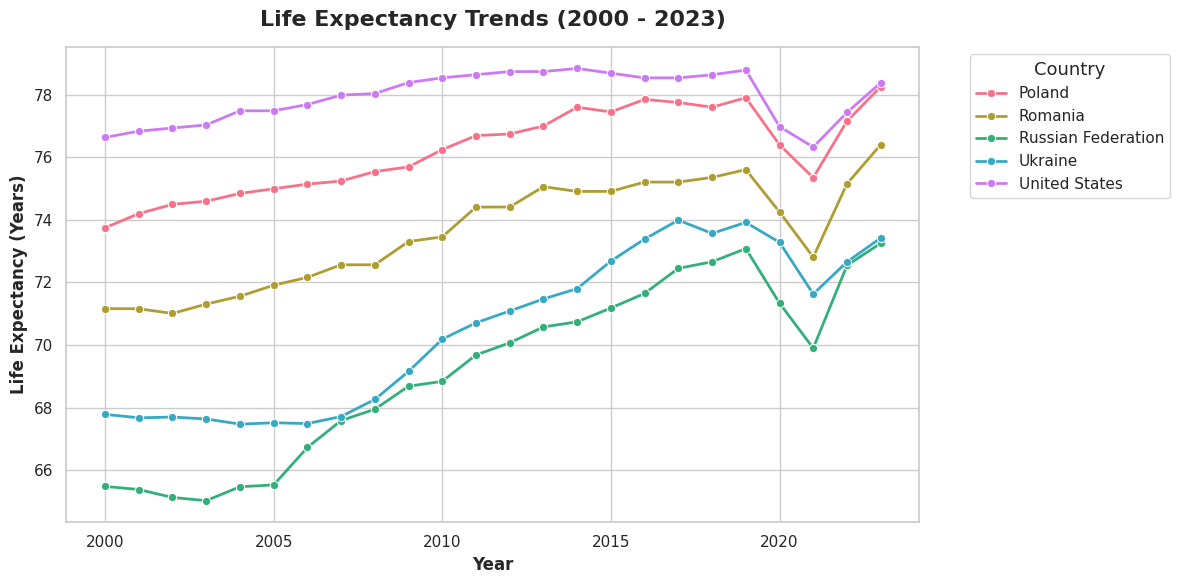

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sqlite3

# 1. Re-connect to the database to grab the full time-series data
conn = sqlite3.connect('wdi_population.db')
df_full = pd.read_sql_query("SELECT * FROM population_data", conn)
conn.close()

# 2. Set up the visual aesthetics
# Using a clean white grid and a visually distinct color palette
sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("husl", 5)

# 3. Create the figure
plt.figure(figsize=(12, 6))

# 4. Plot Life Expectancy over time
sns.lineplot(
    data=df_full,
    x='Year',
    y='Life_Expectancy',
    hue='Country',
    palette=custom_palette,
    marker='o',
    linewidth=2
)

# 5. Format the plot for the final report
plt.title('Life Expectancy Trends (2000 - 2023)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Life Expectancy (Years)', fontsize=12, fontweight='bold')

# Move the legend outside the plot so it doesn't cover the data lines
plt.legend(title='Country', title_fontsize='13', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to ensure nothing gets cut off when you save the image
plt.tight_layout()

# 6. Display the plot
plt.show()

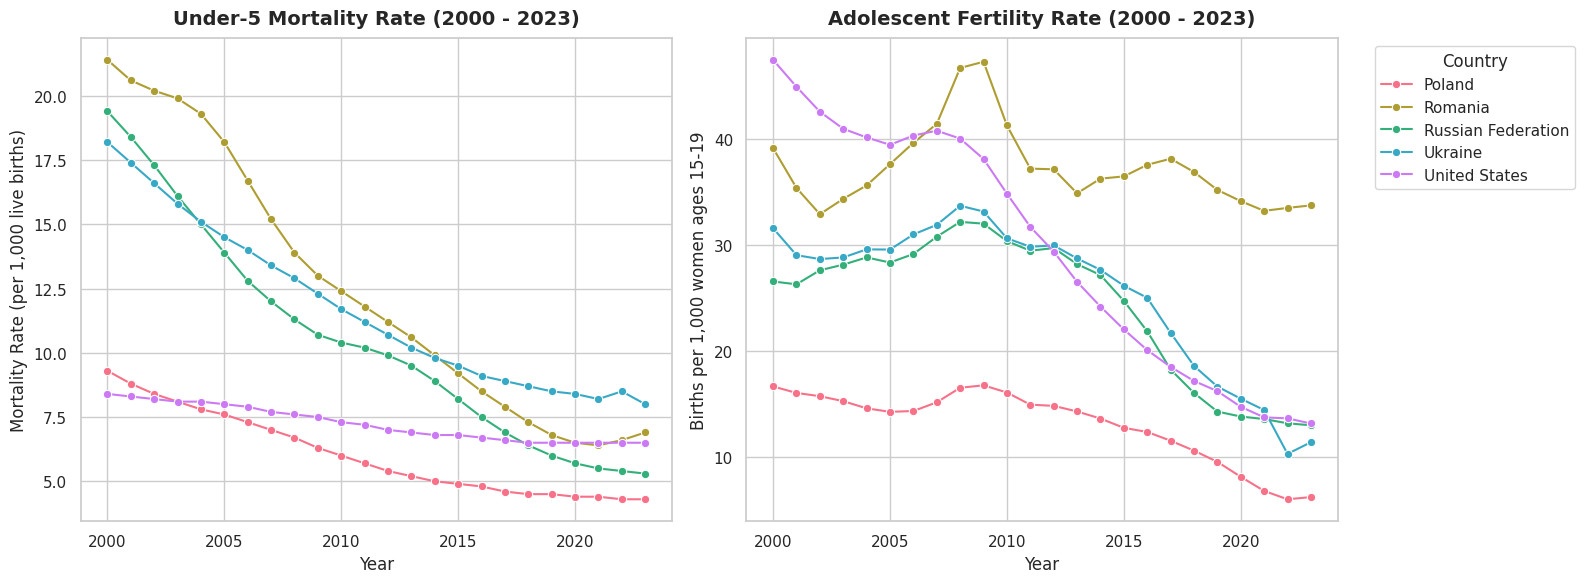

In [7]:
# 1. Create a figure with 1 row and 2 columns for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Plot Under-5 Mortality on the first axis (axes[0])
sns.lineplot(
    data=df_full,
    x='Year',
    y='Under_5_Mortality',
    hue='Country',
    palette=custom_palette,
    marker='o',
    ax=axes[0],
    legend=False # We will share one legend on the right plot
)
axes[0].set_title('Under-5 Mortality Rate (2000 - 2023)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel('Mortality Rate (per 1,000 live births)', fontsize=12)
axes[0].set_xlabel('Year', fontsize=12)

# 3. Plot Adolescent Fertility on the second axis (axes[1])
sns.lineplot(
    data=df_full,
    x='Year',
    y='Adolescent_Fertility',
    hue='Country',
    palette=custom_palette,
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Adolescent Fertility Rate (2000 - 2023)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_ylabel('Births per 1,000 women ages 15-19', fontsize=12)
axes[1].set_xlabel('Year', fontsize=12)

# 4. Format the shared legend outside the second plot
axes[1].legend(title='Country', title_fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

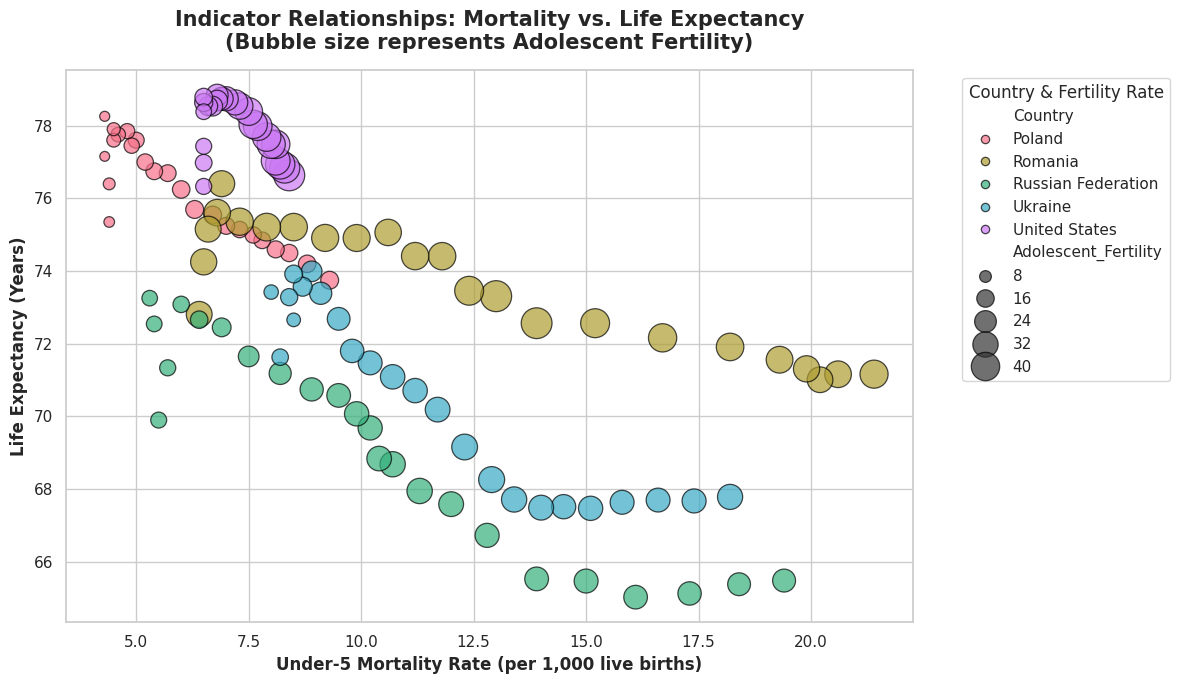

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sqlite3

# Re-fetch data just to be safe
conn = sqlite3.connect('wdi_population.db')
df_full = pd.read_sql_query("SELECT * FROM population_data", conn)
conn.close()

sns.set_theme(style="whitegrid")
custom_palette = sns.color_palette("husl", 5)

# Create the Bubble Scatter Plot
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_full,
    x='Under_5_Mortality',
    y='Life_Expectancy',
    hue='Country',
    size='Adolescent_Fertility',
    sizes=(50, 500), # Controls the minimum and maximum bubble sizes
    alpha=0.7,       # Adds slight transparency so overlapping bubbles are visible
    palette=custom_palette,
    edgecolor='black'
)

plt.title('Indicator Relationships: Mortality vs. Life Expectancy\n(Bubble size represents Adolescent Fertility)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Under-5 Mortality Rate (per 1,000 live births)', fontsize=12, fontweight='bold')
plt.ylabel('Life Expectancy (Years)', fontsize=12, fontweight='bold')

# Format the legend to be outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Country & Fertility Rate")
plt.tight_layout()
plt.show()

/tmp/ipykernel_3898/3508157233.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


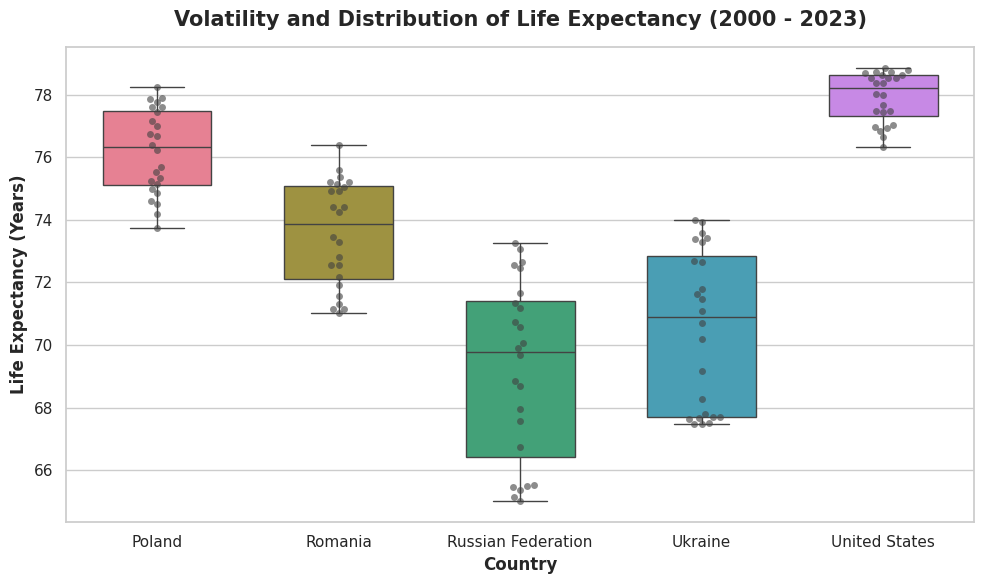

In [9]:
# Create a Box Plot for Life Expectancy spread
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_full,
    x='Country',
    y='Life_Expectancy',
    palette=custom_palette,
    width=0.6,
    fliersize=5 # Makes outliers more visible
)

# Overlay a "swarm plot" to show the actual individual data points (years) inside the boxes
sns.swarmplot(
    data=df_full,
    x='Country',
    y='Life_Expectancy',
    color=".25", # Dark gray dots
    alpha=0.6
)

plt.title('Volatility and Distribution of Life Expectancy (2000 - 2023)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Life Expectancy (Years)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

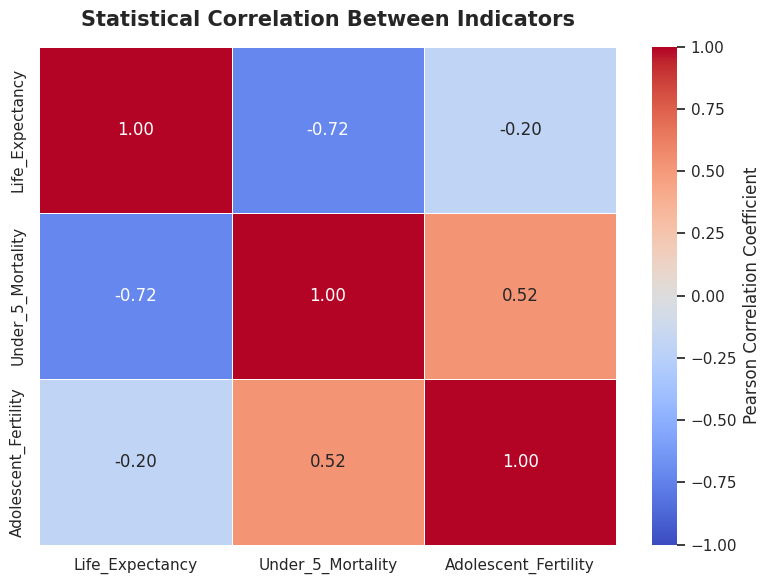

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sqlite3

# 1. Fetch data
conn = sqlite3.connect('wdi_population.db')
df_full = pd.read_sql_query("SELECT * FROM population_data", conn)
conn.close()

# 2. Calculate the correlation matrix for the numeric indicators
corr_matrix = df_full[['Life_Expectancy', 'Under_5_Mortality', 'Adolescent_Fertility']].corr()

# 3. Create the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the actual correlation numbers
    cmap='coolwarm',     # Blue for negative correlation, Red for positive
    vmin=-1, vmax=1,     # Set the scale from -1 to 1
    fmt=".2f",           # Round to 2 decimal places
    linewidths=.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title('Statistical Correlation Between Indicators', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3898/1841940336.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


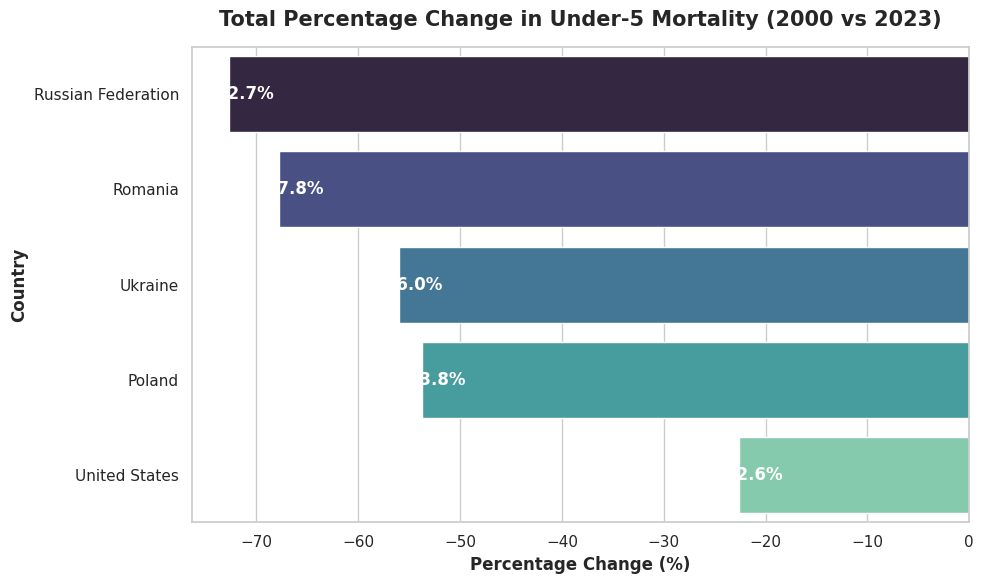

In [11]:
# 1. Ensure the 'Year' column is numeric for proper filtering
df_full['Year'] = pd.to_numeric(df_full['Year'])

# 2. Isolate the data for the starting year (2000) and the ending year (2023)
df_start = df_full[df_full['Year'] == 2000].set_index('Country')
df_end = df_full[df_full['Year'] == df_full['Year'].max()].set_index('Country')

# 3. Calculate the overall percentage change for Under-5 Mortality
pct_change_mortality = ((df_end['Under_5_Mortality'] - df_start['Under_5_Mortality']) / df_start['Under_5_Mortality']) * 100

# Sort the values so the chart is ordered from most improvement to least
pct_change_mortality = pct_change_mortality.sort_values()

# 4. Create a horizontal bar chart
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x=pct_change_mortality.values,
    y=pct_change_mortality.index,
    palette='mako'
)

plt.title('Total Percentage Change in Under-5 Mortality (2000 vs 2023)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Percentage Change (%)', fontsize=12, fontweight='bold')
plt.ylabel('Country', fontsize=12, fontweight='bold')

# 5. Add the actual percentage numbers onto the bars for clarity
for i, v in enumerate(pct_change_mortality.values):
    plt.text(v - 2, i, f"{v:.1f}%", color='white', va='center', fontweight='bold')

plt.tight_layout()
plt.show()